In [1]:
# conda activate chronocell

import sys
import glob
import pickle
import numpy as np
import pandas as pd
from functools import reduce

sys.path.append("/mnt/lareaulab/reliscu/programs/FGP_2024")
sys.path.append("code")

import Chronocell
from impute_protein import *

In [2]:
prefix = "janssens_2025_preprint_Chronocell_eLNPs_var>1.5"

In [3]:
# Get traj object from running Chronocell
import pickle
with open(f"data/{prefix}_traj_WS.pkl", "rb") as f:
    traj = pickle.load(f)

In [5]:
t = traj.t
Q = traj.Q[:, 0, :] # Need to know where each cell starts from

# Y = traj.X
# tau = traj.tau # State transition times (global)
#  = traj.t
# theta = traj.theta
# topo = traj.topo
# state_grid = np.searchsorted(tau, t, side="left") - 1
# state_grid[0] = 0 
## Get genes of interest

In [7]:
genes = pd.read_csv(f"data/{prefix}_traj_X_colnames.csv") # Order of genes in Chronocell object
mapped_identifiers = pd.read_csv("data/janssens_2025_preprint_author_counts_eLNP_RNA_vs_ADT_corrs.csv")
gene_idx = genes['Gene_symbol'].isin(mapped_identifiers['Gene']).tolist()

In [8]:
genes.iloc[gene_idx]['Gene_symbol'].tolist()

['Cxcr4',
 'Icos',
 'Cd48',
 'Cd24a',
 'Cd63',
 'Cd68',
 'Ccr7',
 'Cd300c2',
 'Havcr2',
 'Ighm',
 'Irf4',
 'Cd83',
 'Lgals3',
 'Il7r',
 'Ly6e',
 'Cd86',
 'Cd200',
 'Cd80',
 'Btla',
 'Ms4a1',
 'Cd274',
 'Fas',
 'Entpd1',
 'Dpp4',
 'Itga4',
 'Procr',
 'Cd1d1',
 'Vcam1',
 'Notch2',
 'Tnfrsf4',
 'Tnfrsf18',
 'Cd36',
 'Flt3',
 'Cd38',
 'Kit',
 'Cd207',
 'Cd9',
 'Klrk1',
 'Cd8a',
 'Clec12a',
 'Clec9a',
 'Pirb',
 'Il4ra',
 'Itgal',
 'Itgax',
 'Bst2',
 'Lamp1',
 'Itgb1',
 'Fut4',
 'Xcr1',
 'Icam1',
 'Jaml']

## Get half-life data

In [9]:
data_dir = "/mnt/lareaulab/reliscu/projects/Chronocell/data/experimental_parameters/protein_degradation_rates"
file_list = glob.glob(f"{data_dir}/*standardized.csv")
subset_columns = ['Gene', 'Half-life']

df_list = []
for file in [file for file in file_list if "Mouse" in file]:
    df = pd.read_csv(file)
    study = df['Study'].iloc[0]
    cell_type = df['Cell_type'].iloc[0]
    df = df[subset_columns]
    df = df.rename(columns={"Half-life": f"Half-life_{study}_{cell_type}", 
                            "Cell_type": f"Cell_type_{study}"}) 
    df_list.append(df)

In [10]:
df_list[0].head()

,Gene,Half-life_McShane2016_NIH3T3 fibroblasts
0,Cul4b,31.378265
1,Dhx8,28.700000
2,Znf335,3.599724
3,Arfgef2,24.371302
4,Cdc27,21.057713


In [ ]:
df = reduce(lambda x, y: pd.merge(x, y, on="Gene", how="outer"), df_list)

In [12]:
df.shape

(20227, 8)

## Subset half-life data to genes of interest

In [13]:
df_subset = df.loc[df['Gene'].isin(genes.iloc[gene_idx]['Gene_symbol'])]

In [14]:
df_subset.reset_index(drop=True)

,Gene,Half-life_McShane2016_NIH3T3 fibroblasts,Half-life_Schwanhausser2011_NIH3T3 fibroblasts,Half-life_Fornasiero2018_Leg-muscle,Half-life_Matsuda2024_Induced presomitic mesoderm cells,Half-life_Cambridge2011_C2C12 myoblasts,Half-life_Mathieson2018_Embryonic neurons,Half-life_Fornasiero2018_Heart
0,Bst2,NaN,8.89,NaN,NaN,NaN,NaN,NaN
1,Cd63,19.953640,57.49,NaN,NaN,NaN,NaN,NaN
2,Cd9,NaN,32.19,NaN,NaN,NaN,NaN,NaN
3,Itgb1,63.400000,11.75,60.0,NaN,28.3,NaN,62.88
4,Lamp1,NaN,30.18,NaN,NaN,38.7,NaN,35.04
5,Lgals3,115.005279,60.99,NaN,NaN,44.3,NaN,NaN
6,Notch2,9.629458,6.13,NaN,NaN,15.6,NaN,NaN
7,Procr,NaN,22.27,NaN,NaN,NaN,NaN,NaN
8,Vcam1,12.751839,18.18,NaN,NaN,15.5,NaN,NaN


## Plot distribution of half-life estimates

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as mticker


/tmp/ipykernel_3981264/3302672815.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=90)
/tmp/ipykernel_3981264/3302672815.py:32: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


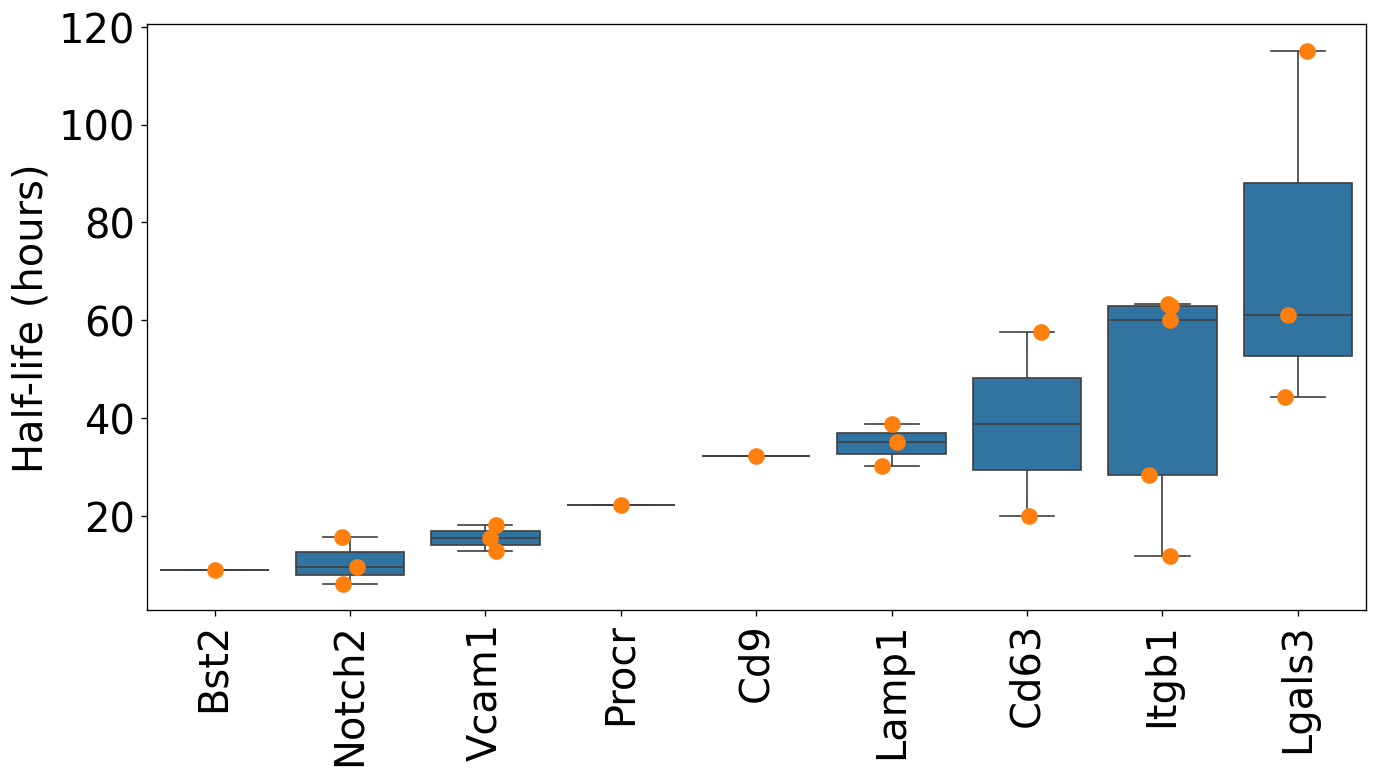

In [20]:
import matplotlib.ticker as mticker

id_col = "Gene"

value_cols = [c for c in df_subset.columns if c != id_col]

long = (df_subset
        .melt(id_vars=id_col, value_vars=value_cols,
              var_name="source", value_name="half_life")
        .dropna(subset=["half_life"]))

# order genes by mean half_life (ascending). Use .sort_values(ascending=False) for descending.
gene_order = (long.groupby(id_col)["half_life"]
                  .mean()
                  .sort_values()
                  .index
                  .tolist())

fig, ax = plt.subplots(figsize=(12, 7), dpi=120)

ax.yaxis.set_major_locator(mticker.MultipleLocator(20))
# ax.grid(True, which="major", axis="y")

sns.boxplot(data=long, x=id_col, y="half_life", order=gene_order, ax=ax)
sns.stripplot(data=long, x=id_col, y="half_life",
              order=gene_order, jitter=True, alpha=1, size=10, ax=ax)

ax.set_xticklabels(ax.get_xticklabels(), rotation=90)
ax.set_xlabel("")
ax.set_ylabel("Half-life (hours)")

plt.tight_layout()
plt.show()


/tmp/ipykernel_3981264/1767523023.py:30: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=90)
/tmp/ipykernel_3981264/1767523023.py:34: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


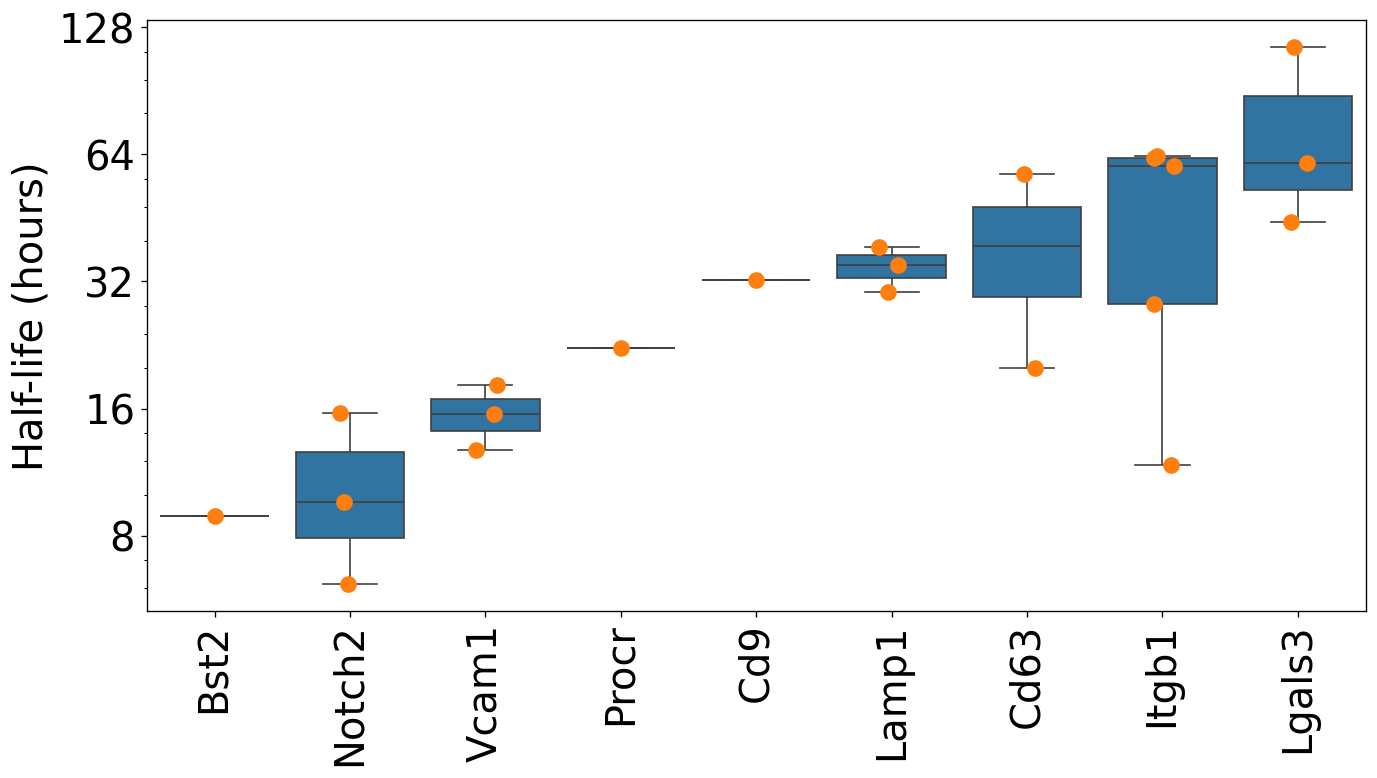

In [22]:
import numpy as np

fig, ax = plt.subplots(figsize=(12, 7), dpi=120)

sns.boxplot(data=long, x=id_col, y="half_life", order=gene_order, ax=ax)
sns.stripplot(data=long, x=id_col, y="half_life",
              order=gene_order, jitter=True, alpha=1, size=10, ax=ax)

import matplotlib.ticker as mticker

ax.set_yscale("log", base=2)

# put major ticks at powers of 2, but label them as plain numbers (1, 2, 4, 8, 16...)
ax.yaxis.set_major_locator(mticker.LogLocator(base=2))
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda y, _: f"{y:g}"))

# optional: minor ticks (no labels)
ax.yaxis.set_minor_locator(mticker.LogLocator(base=2, subs=(1.25, 1.5, 1.75)))
ax.yaxis.set_minor_formatter(mticker.NullFormatter())

ax.set_xticklabels(ax.get_xticklabels(), rotation=90)
ax.set_xlabel("")
ax.set_ylabel("Half-life (hours)")

plt.tight_layout()
plt.show()


## Convert half-life to degradation rate

In [25]:
half_life_cols = [col for col in df_subset.columns if "Half-life" in col]
df_deg = np.log(2)/df_subset[half_life_cols]
median_deg = np.nanmedian(df_deg, axis=1)

In [56]:
df_deg["Gene"] = df_subset["Gene"].to_numpy()

In [57]:
df_deg

,Half-life_McShane2016_NIH3T3 fibroblasts,Half-life_Schwanhausser2011_NIH3T3 fibroblasts,Half-life_Fornasiero2018_Leg-muscle,Half-life_Matsuda2024_Induced presomitic mesoderm cells,Half-life_Cambridge2011_C2C12 myoblasts,Half-life_Mathieson2018_Embryonic neurons,Half-life_Fornasiero2018_Heart,Gene
Gene,,,,,,,,
Bst2,NaN,0.077969,NaN,NaN,NaN,NaN,NaN,Bst2
Cd63,0.034738,0.012057,NaN,NaN,NaN,NaN,NaN,Cd63
Cd9,NaN,0.021533,NaN,NaN,NaN,NaN,NaN,Cd9
Itgb1,0.010933,0.058991,0.011552,NaN,0.024493,NaN,0.011023,Itgb1
Lamp1,NaN,0.022967,NaN,NaN,0.017911,NaN,0.019782,Lamp1
Lgals3,0.006027,0.011365,NaN,NaN,0.015647,NaN,NaN,Lgals3
Notch2,0.071982,0.113075,NaN,NaN,0.044433,NaN,NaN,Notch2
Procr,NaN,0.031125,NaN,NaN,NaN,NaN,NaN,Procr
Vcam1,0.054357,0.038127,NaN,NaN,0.044719,NaN,NaN,Vcam1


/tmp/ipykernel_3981264/1649844962.py:32: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=90)
/tmp/ipykernel_3981264/1649844962.py:36: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


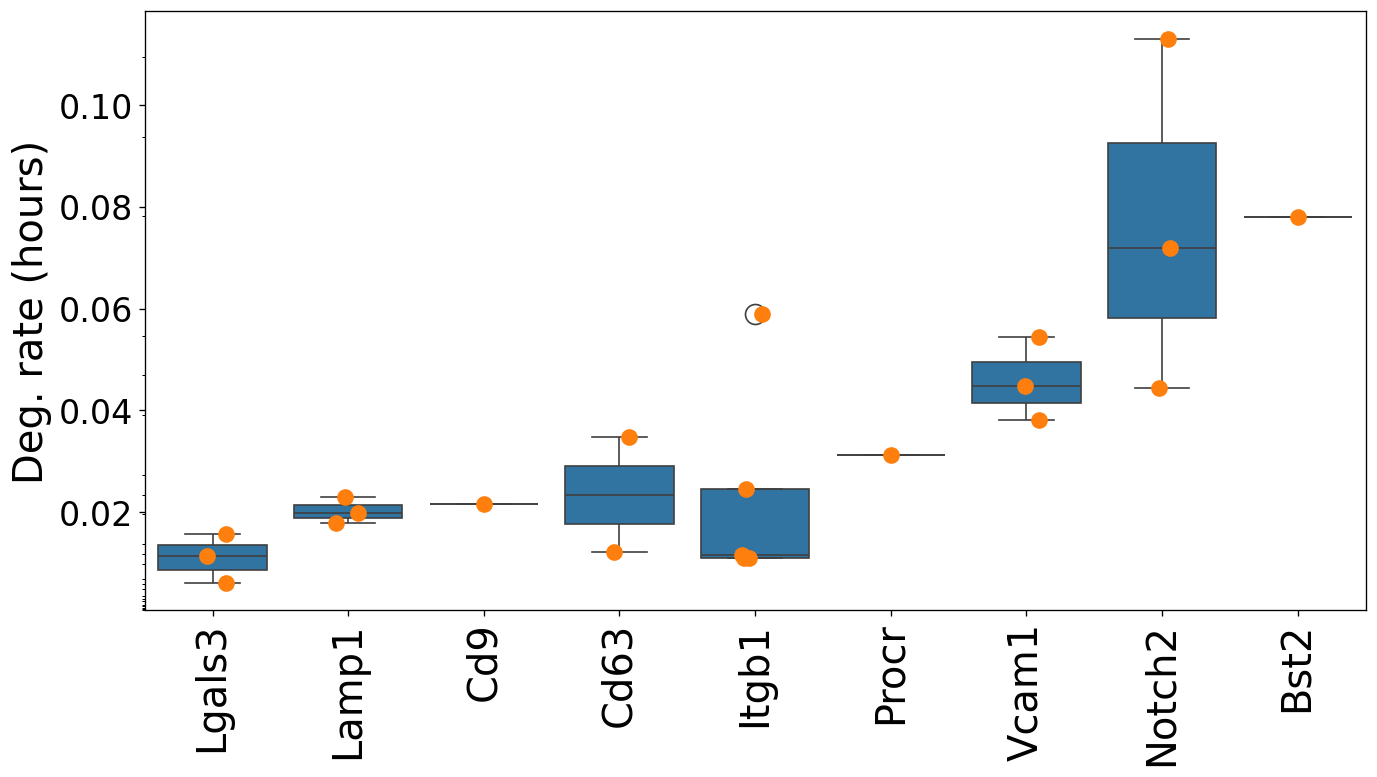

In [64]:
import matplotlib.ticker as mticker

id_col = "Gene"

value_cols = [c for c in df_deg.columns if c != id_col]

long = (df_deg
        .melt(id_vars=id_col, value_vars=value_cols,
              var_name="source", value_name="deg_rate")
        .dropna(subset=["deg_rate"]))

# order genes by mean half_life (ascending). Use .sort_values(ascending=False) for descending.
gene_order = (long.groupby(id_col)["deg_rate"]
                  .mean()
                  .sort_values()
                  .index
                  .tolist())

fig, ax = plt.subplots(figsize=(12, 7), dpi=120)

# ax.grid(True, which="major", axis="y")
ax.tick_params(axis="y", labelsize=20)

# optional: minor ticks (no labels)
ax.yaxis.set_minor_locator(mticker.LogLocator(base=2, subs=(1.25, 1.5, 1.75)))
ax.yaxis.set_minor_formatter(mticker.NullFormatter())

sns.boxplot(data=long, x=id_col, y="deg_rate", order=gene_order, ax=ax)
sns.stripplot(data=long, x=id_col, y="deg_rate",
              order=gene_order, jitter=True, alpha=1, size=10, ax=ax)

ax.set_xticklabels(ax.get_xticklabels(), rotation=90)
ax.set_xlabel("")
ax.set_ylabel("Deg. rate (hours)")

plt.tight_layout()
plt.show()


/tmp/ipykernel_3981264/620137111.py:24: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=90)
/tmp/ipykernel_3981264/620137111.py:28: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


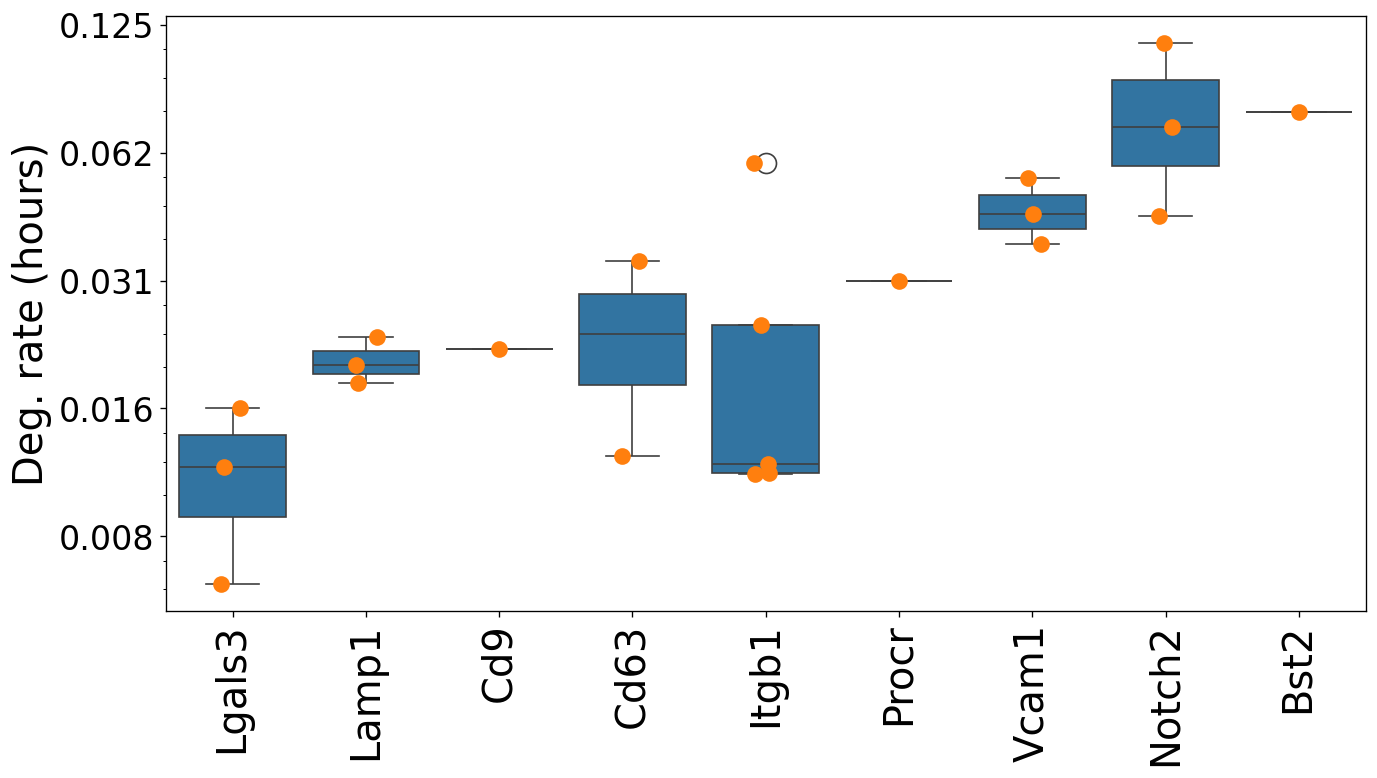

In [62]:
import numpy as np

fig, ax = plt.subplots(figsize=(12, 7), dpi=120)

sns.boxplot(data=long, x=id_col, y="deg_rate", order=gene_order, ax=ax)
sns.stripplot(data=long, x=id_col, y="deg_rate",
              order=gene_order, jitter=True, alpha=1, size=10, ax=ax)

import matplotlib.ticker as mticker

ax.set_yscale("log", base=2)

# put major ticks at powers of 2, but label them as plain numbers (1, 2, 4, 8, 16...)
ax.yaxis.set_major_locator(mticker.LogLocator(base=2))
ax.yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda y, _: f"{y:.3f}".rstrip("0").rstrip("."))
)
ax.tick_params(axis="y", labelsize=20)

# optional: minor ticks (no labels)
ax.yaxis.set_minor_locator(mticker.LogLocator(base=2, subs=(1.25, 1.5, 1.75)))
ax.yaxis.set_minor_formatter(mticker.NullFormatter())

ax.set_xticklabels(ax.get_xticklabels(), rotation=90)
ax.set_xlabel("")
ax.set_ylabel("Deg. rate (hours)")

plt.tight_layout()
plt.show()


In [24]:
df_subset['Gene']

1962       Bst2
2973       Cd63
2976        Cd9
7683      Itgb1
8793      Lamp1
8875     Lgals3
11057    Notch2
12968     Procr
18975     Vcam1
Name: Gene, dtype: object

## Impute protein

In [65]:
Q.shape

(21325, 100)

In [66]:
n_genes = df_subset.shape[0]
n_cells = Q.shape[0]

P = np.full((n_cells, n_genes), -1)

for idx, gene in enumerate(df_subset['Gene']):
    file_path = f"data/RNA_history_per_gene/{prefix}_{gene}_S_RNA_history.pkl"

    with open(file_path, "rb") as f:
        X_bw = pickle.load(f)
    
    deg_rate = median_deg[idx]    
    
    P[:, idx] = impute_protein(X_bw, Q, t, deg_rate, transl_rate=1)

In [67]:
P.shape

(21325, 9)

In [68]:
P_df = pd.DataFrame(P, columns=df_subset['Gene'].tolist())
P_df.head()


,Bst2,Cd63,Cd9,Itgb1,Lamp1,Lgals3,Notch2,Procr,Vcam1
0,10,79,45,174,47,714,0,0,0
1,9,78,50,86,47,721,0,2,0
2,11,82,46,86,49,710,0,0,0
3,12,83,0,0,49,707,0,0,0
4,9,79,48,86,48,719,0,0,0


In [69]:
P_df = pd.DataFrame(P, columns=df_subset['Gene'].tolist())
P_df.head()


,Bst2,Cd63,Cd9,Itgb1,Lamp1,Lgals3,Notch2,Procr,Vcam1
0,10,79,45,174,47,714,0,0,0
1,9,78,50,86,47,721,0,2,0
2,11,82,46,86,49,710,0,0,0
3,12,83,0,0,49,707,0,0,0
4,9,79,48,86,48,719,0,0,0


In [71]:
P_df.shape

(21325, 9)

In [70]:
P_df.to_csv(f"data/{prefix}_RNA_history_imputed_protein.csv", index=False)

## Visualize protein vs. observed RNA per cell

In [ ]:
import sys
import pickle

In [136]:
# Load in traj object to get RNA counts
# Load in gene identifier info
# Subset to genes in P_df

prefix = "janssens_2025_preprint_Chronocell_eLNPs_var>1.5"

# Get traj object from running Chronocell

with open(f"data/{prefix}_traj_WS.pkl", "rb") as f:
    traj = pickle.load(f)

# Extract varies objects/parameters needed to simulate data

Y = traj.X
Q = traj.Q[:, 0, :] 
t = traj.t

# Subset data to genes of interest (with protein measurements)

genes = pd.read_csv(f"data/{prefix}_traj_X_colnames.csv") # Order of genes in Chronocell object
mapped_identifiers = pd.read_csv("data/janssens_2025_preprint_author_counts_eLNP_RNA_vs_ADT_corrs.csv")
gene_mask = genes['Gene_symbol'].isin(mapped_identifiers['Gene']).tolist() # Genes to focus on
genes = genes.loc[gene_mask,]

Y = Y[:, gene_mask, :]
# Get estimate time for each cell

t_per_cell = t[Q.argmax(axis=1)]
t_per_cell

array([3.07070707, 3.87878788, 1.6969697 , ..., 5.25252525, 0.08080808,
       5.49494949])

In [166]:
i = 3

w_gene = P_df.columns[i]
print(w_gene)

gene_idx = np.where(genes == w_gene)[0][0]
gene_idx

Itgb1


np.int64(47)

In [167]:
sys.path.append("code")

from reconstruct_RNA_history import *

# Get forward trajectories

with open(f"data/{prefix}_X_fwd_per_gene.pkl", "rb") as f:
    X_fwd_per_gene = pickle.load(f)
    
with open(f"data/{prefix}_states_per_gene.pkl", "rb") as f:
    states_per_gene = pickle.load(f)
    
states = states_per_gene[gene_idx]
X_fwd = X_fwd_per_gene[gene_idx]
U_fwd, S_fwd = highest_prob_state_in_X_fwd(X_fwd, states)

len(X_fwd_per_gene)

52

Text(0, 0.5, '# molecules')

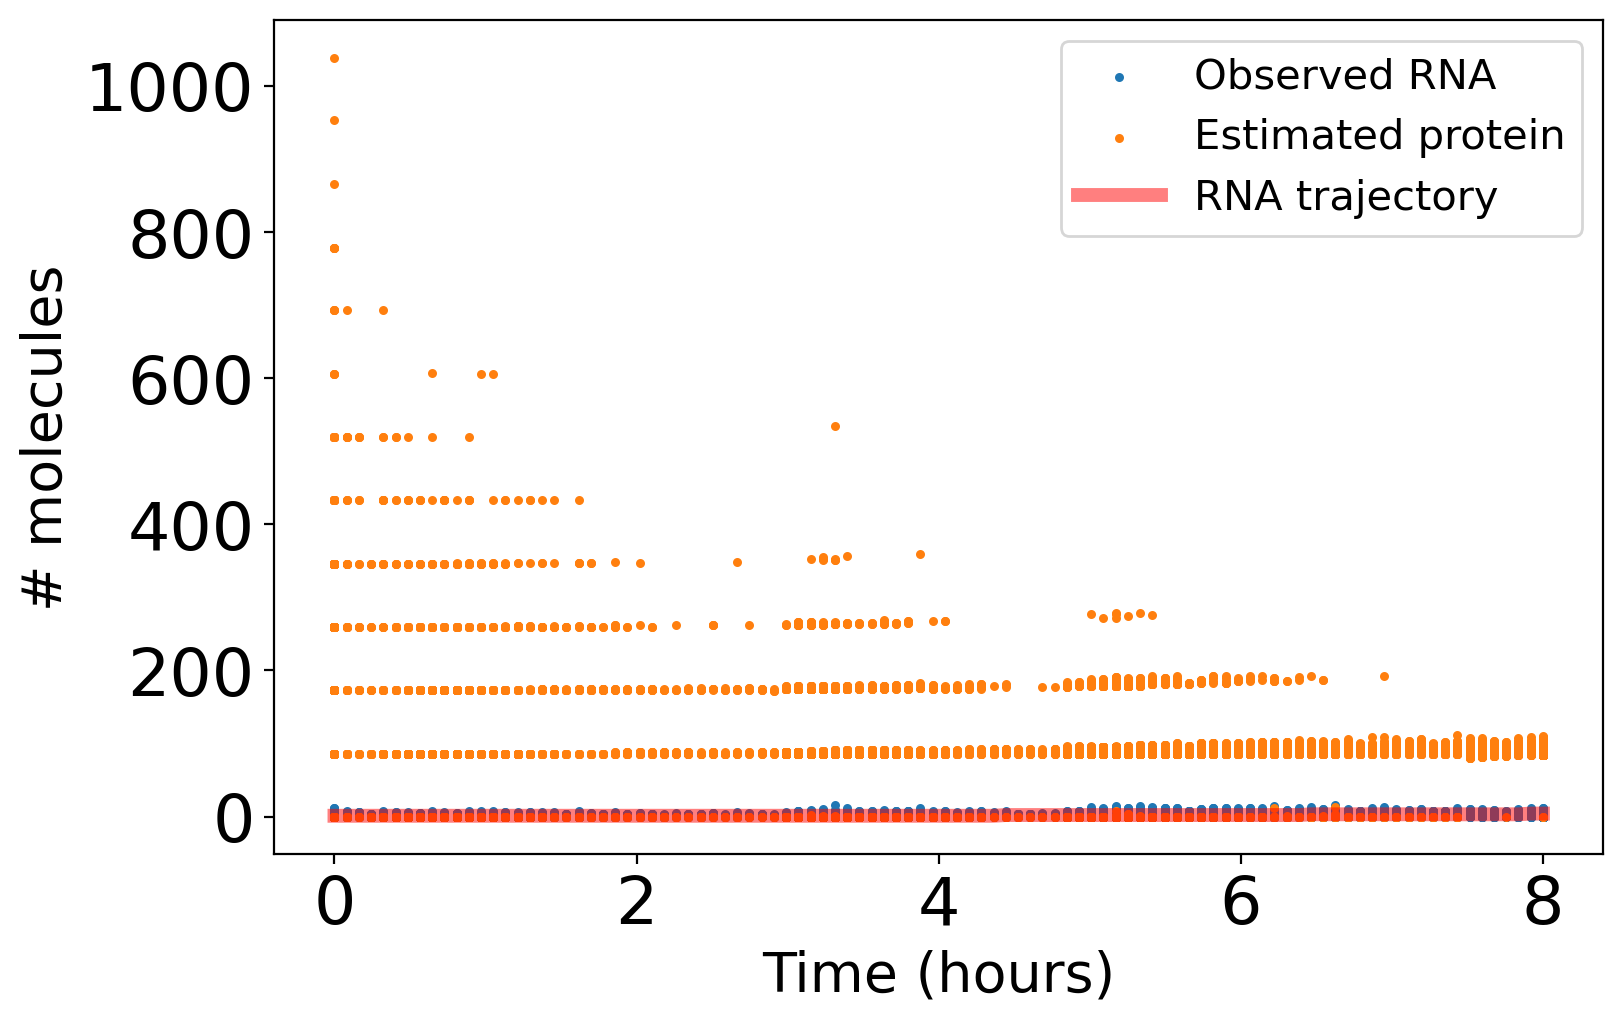

In [172]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 5), dpi=200)  # display dpi
ax.scatter(t_per_cell, Y[:, gene_idx, 1], s=5, label="Observed RNA")
ax.scatter(t_per_cell, P_df[w_gene], s=5, label="Estimated protein")
ax.plot(t, S_fwd, label="RNA trajectory", color="red", linewidth=5, alpha=0.5)

ax.legend(fontsize=15)
ax.set_xlabel("Time (hours)", fontsize=20)
ax.set_ylabel("# molecules", fontsize=20)

(-1.0, 20.0)

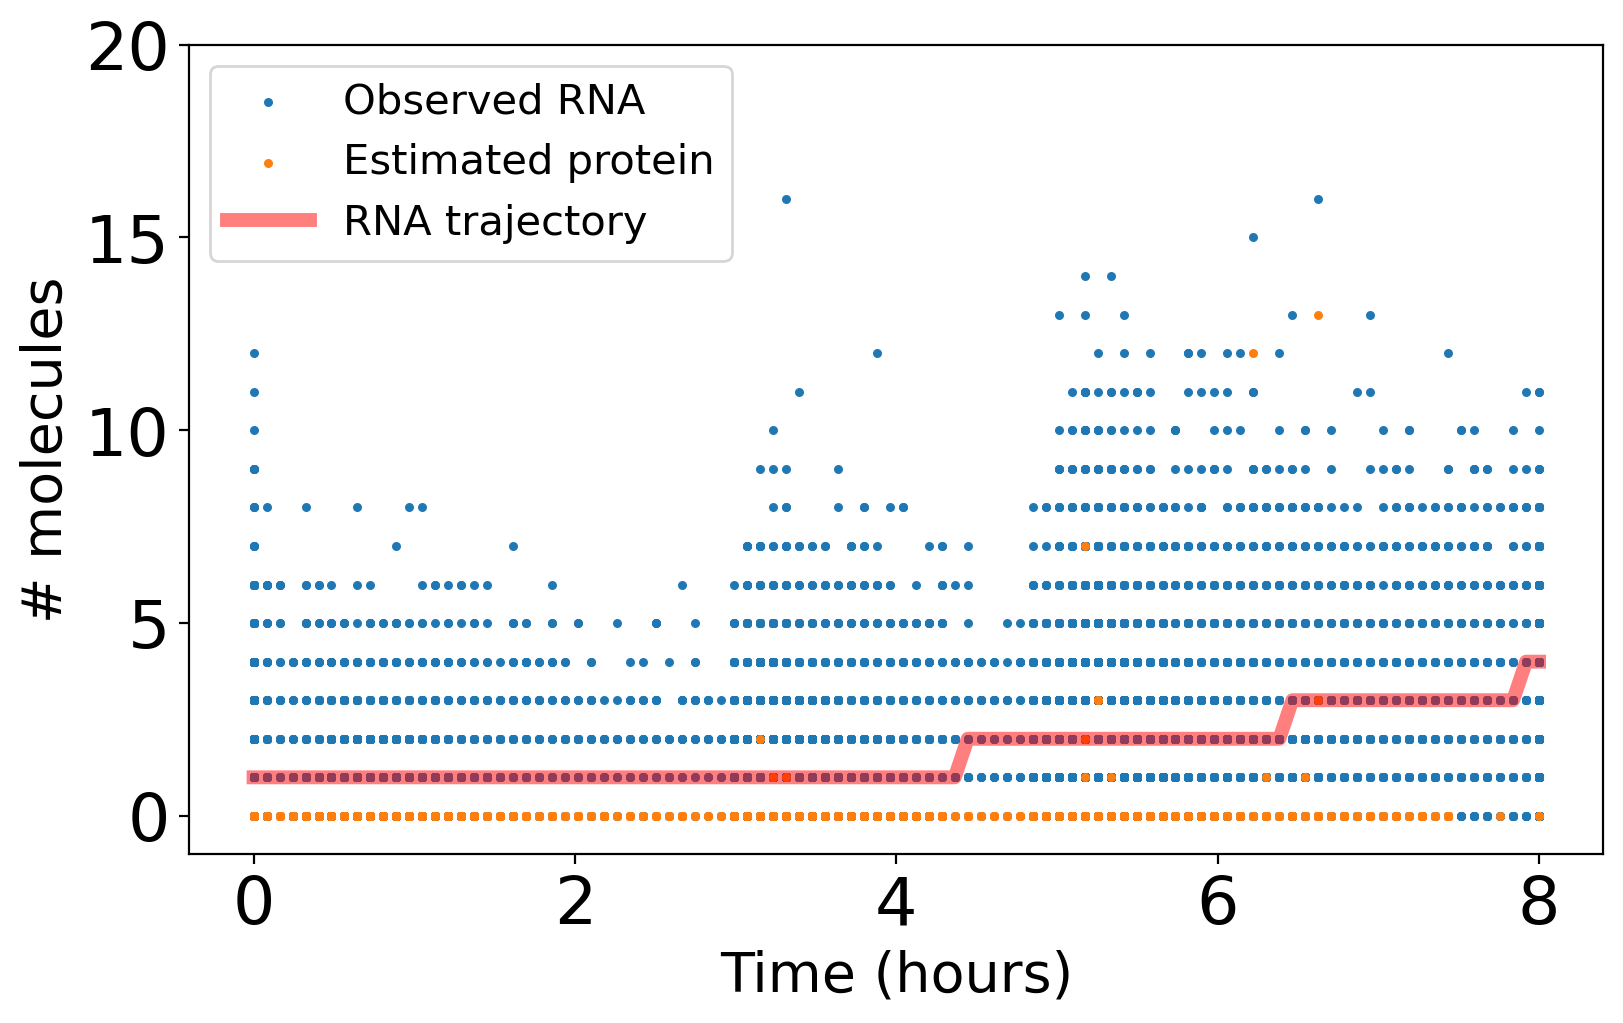

In [173]:
# Zoom in

fig, ax = plt.subplots(figsize=(8, 5), dpi=200)  # display dpi
ax.scatter(t_per_cell, Y[:, gene_idx, 1], s=5, label="Observed RNA")
ax.scatter(t_per_cell, P_df[w_gene], s=5, label="Estimated protein")
ax.plot(t, S_fwd, label="RNA trajectory", color="red", linewidth=5, alpha=0.5)

ax.legend(fontsize=15)
ax.set_xlabel("Time (hours)", fontsize=20)
ax.set_ylabel("# molecules", fontsize=20)

ax.set_ylim((-1, 20))

In [170]:
P_df[w_gene]

0        174
1         86
2         86
3          0
4         86
        ... 
21320    173
21321     86
21322     95
21323    173
21324     86
Name: Itgb1, Length: 21325, dtype: int64

(-1.0, 100.0)

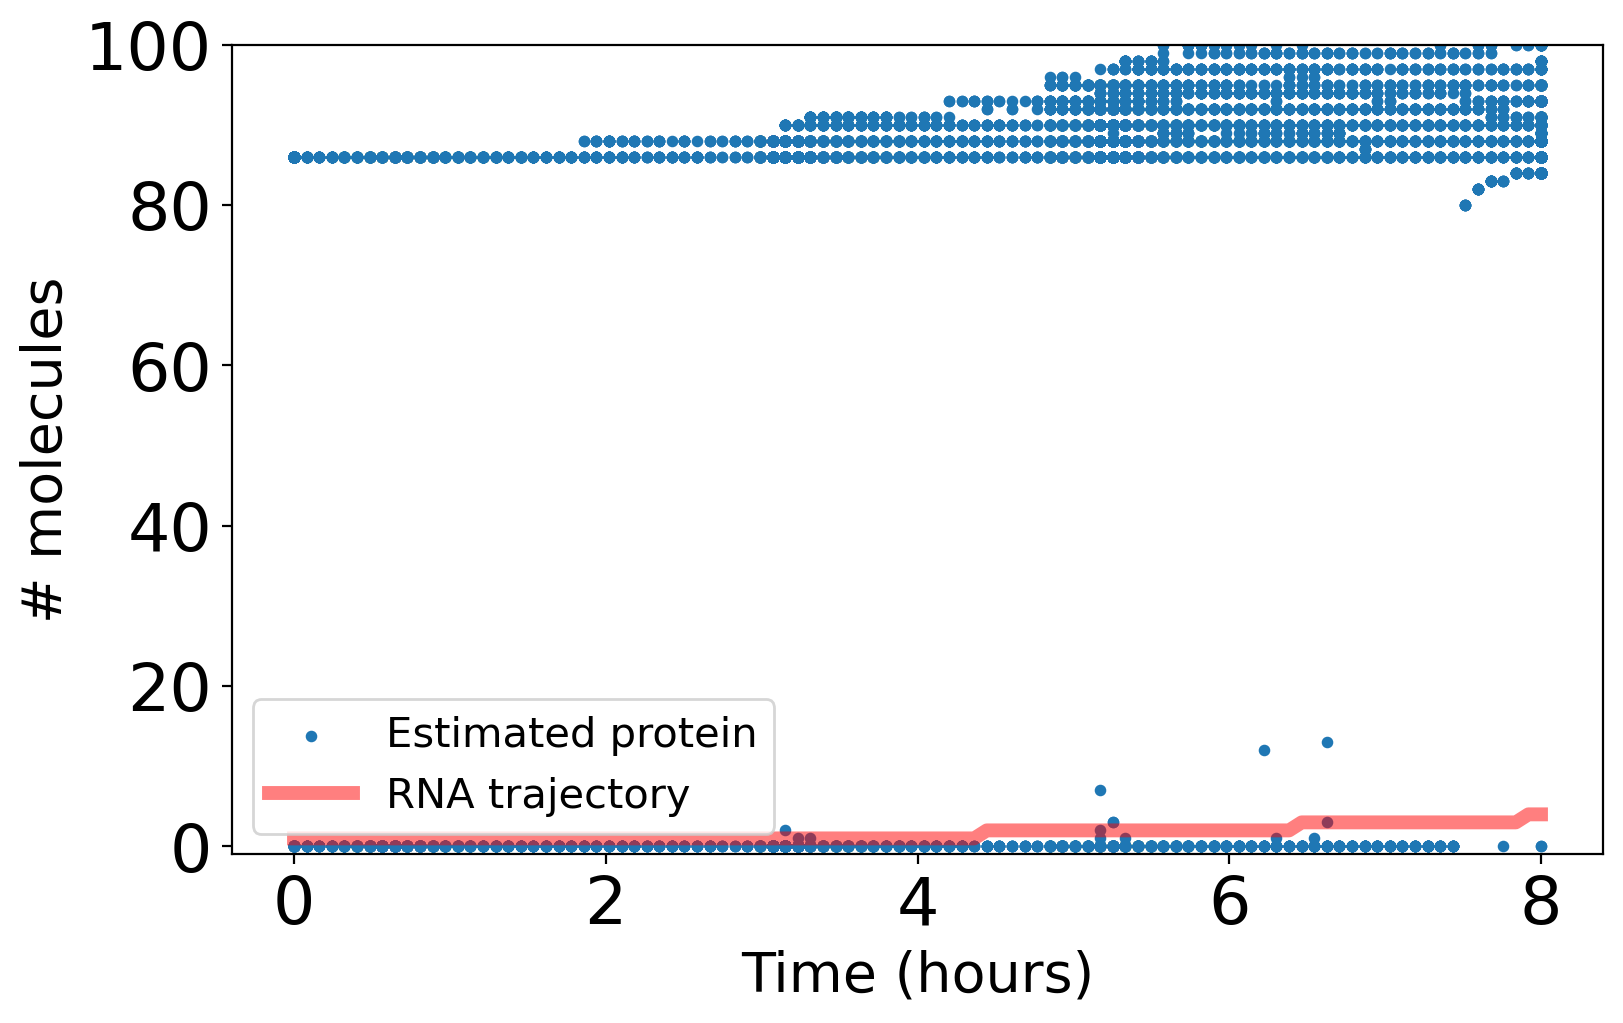

In [174]:
fig, ax = plt.subplots(figsize=(8, 5), dpi=200)
ax.scatter(t_per_cell, P_df[w_gene], s=10, label="Estimated protein")
ax.plot(t, S_fwd, label="RNA trajectory", color="red", linewidth=5, alpha=0.5)
ax.legend(fontsize=15)

ax.set_xlabel("Time (hours)", fontsize=20)
ax.set_ylabel("# molecules", fontsize=20)
ax.set_ylim((-1, 100))

In [ ]:
# Why do some genes have 0 RNA (and therefore 0 protein, seemingly)?

In [183]:
import os 

# Load backward trajectories
pattern = os.path.join("data/RNA_history_per_gene", f"*_{w_gene}_S*")
file = glob.glob(pattern)[0]

print(file)

with open(file, "rb") as f:
    X_bw_S = pickle.load(f)

data/RNA_history_per_gene/janssens_2025_preprint_Chronocell_eLNPs_var>1.5_Itgb1_S_RNA_history.pkl


In [192]:
np.where((P_df[w_gene] == 0) & (t_per_cell > 6))[0][:10]

array([3160, 5990, 6000, 7555, 8039, 8344, 8349, 9221, 9287, 9510])

In [194]:
X_bw_S[3160, :]

array([ 1,  1,  1,  1,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,
        2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  3,  3,  3,  3,  3,
        3,  3,  3,  3,  3,  3,  3,  3,  3,  3,  3, -1, -1, -1, -1, -1, -1,
       -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1,
       -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1,
       -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1])

In [195]:
# Looks like they just don't have any RNA imputed 